In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## Merged original training and testing set to apply K-Fold 

In [2]:
train = "./DS/iec104_custom_script_train_final.csv"
test = "./DS/iec104_custom_script_test_final.csv"
output_file = "./DS/original_ds.csv"

df1 = pd.read_csv(train)
df2 = pd.read_csv(test)

merged_df = pd.concat([df1, df2], ignore_index=True)

merged_df.to_csv(output_file, index=False)


In [3]:
original = pd.read_csv("/home/soc/hungnt/CSLID/DS/original_ds.csv")

In [4]:
print(original.head())

   flow idle time max  flow idle time min  flow idle time mean  \
0           10.017000            8.343732             9.457217   
1           10.015363           10.012182            10.013772   
2           10.013702           10.010860            10.012281   
3           10.021219            8.327672             9.454414   
4           10.014834            9.261882             9.758936   

   flow idle time std  flow idle time variance  flow active time max  \
0            0.964311                 0.929896              0.953126   
1           -1.000000                -1.000000              6.161148   
2           -1.000000                -1.000000              0.957219   
3            0.975793                 0.952172              0.624661   
4            0.430525                 0.185352              1.700287   

   flow active time min  flow active time mean  flow active time std  \
0              0.000000               0.241782              0.474243   
1              0.008979   

In [5]:
print(original['Label'])

0       c_ci_na_1_DoS
1       c_ci_na_1_DoS
2       c_ci_na_1_DoS
3       c_ci_na_1_DoS
4       c_ci_na_1_DoS
            ...      
6823    m_sp_na_1_DoS
6824    m_sp_na_1_DoS
6825    m_sp_na_1_DoS
6826    m_sp_na_1_DoS
6827    m_sp_na_1_DoS
Name: Label, Length: 6828, dtype: object


## K-Fold

In [6]:
def multiclass_kfold_cv(X, y, model, n_splits=5):
    """Multi-class K-Fold Cross-Validation"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Metrics storage
    metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1_score': []
    }
    
    # Track best fold
    best_fold = -1
    best_f1_score = -np.inf
    best_train_index, best_val_index = None, None
    
    # Detailed per-fold tracking
    class_reports = []
    confusion_matrices = []
    
    for fold, (train_index, val_index) in enumerate(kf.split(X), 1):
        # Data split
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # Model training
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        # Metrics calculation
        f1 = f1_score(y_true=y_val, y_pred=y_pred, average='weighted')
        metrics['accuracy'].append(accuracy_score(y_true=y_val, y_pred=y_pred))
        metrics['precision'].append(precision_score(y_true=y_val, y_pred=y_pred, average='weighted'))
        metrics['recall'].append(recall_score(y_true=y_val, y_pred=y_pred, average='weighted'))
        metrics['f1_score'].append(f1)
        
        # Check if this fold is the best
        if f1 > best_f1_score:
            best_f1_score = f1
            best_fold = fold
            best_train_index, best_val_index = train_index, val_index
        
        # Detailed reports
        class_reports.append(classification_report(y_true=y_val, y_pred=y_pred, output_dict=True))
        confusion_matrices.append(confusion_matrix(y_true=y_val, y_pred=y_pred))
        
        # Print fold results
        print(f"Fold {fold} Results:")
        print(classification_report(y_true=y_val, y_pred=y_pred))
    
    # Save best fold's data to CSV
    if best_fold != -1:
        best_X_train, best_X_val = X.iloc[best_train_index], X.iloc[best_val_index]
        best_y_train, best_y_val = y.iloc[best_train_index], y.iloc[best_val_index]
        
        train_data = pd.concat([best_X_train, best_y_train.rename("Label")], axis=1)
        test_data = pd.concat([best_X_val, best_y_val.rename("Label")], axis=1)
        
        train_data.to_csv(f"./DS/train_fold_{best_fold}.csv", index=False)
        test_data.to_csv(f"./DS/test_fold_{best_fold}.csv", index=False)
        
        print(f"Best fold: {best_fold} | F1-Score: {best_f1_score:.4f}")
        print(f"Best train and test datasets saved as train_fold_{best_fold}.csv and test_fold_{best_fold}.csv")
    
    # Summary statistics
    summary = {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in metrics.items()}
    
    # Visualization of confusion matrices
    plt.figure(figsize=(15, 3*n_splits))
    for i in range(n_splits):
        plt.subplot(1, n_splits, i+1)
        sns.heatmap(confusion_matrices[i], annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Fold {i+1}')
    plt.tight_layout()
    plt.show()
    
    return summary, class_reports

Fold 1 Results:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       102
         1.0       0.84      0.83      0.83       115
         2.0       0.79      0.84      0.81       138
         3.0       0.78      0.70      0.73       125
         4.0       0.68      0.74      0.71       108
         5.0       1.00      1.00      1.00       125
         6.0       0.71      0.74      0.73       108
         7.0       0.64      0.59      0.62       116
         8.0       0.76      0.79      0.78       102
         9.0       0.56      0.56      0.56       107
        10.0       0.57      0.57      0.57       120
        11.0       1.00      1.00      1.00       100

    accuracy                           0.78      1366
   macro avg       0.78      0.78      0.78      1366
weighted avg       0.78      0.78      0.78      1366

Fold 2 Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   

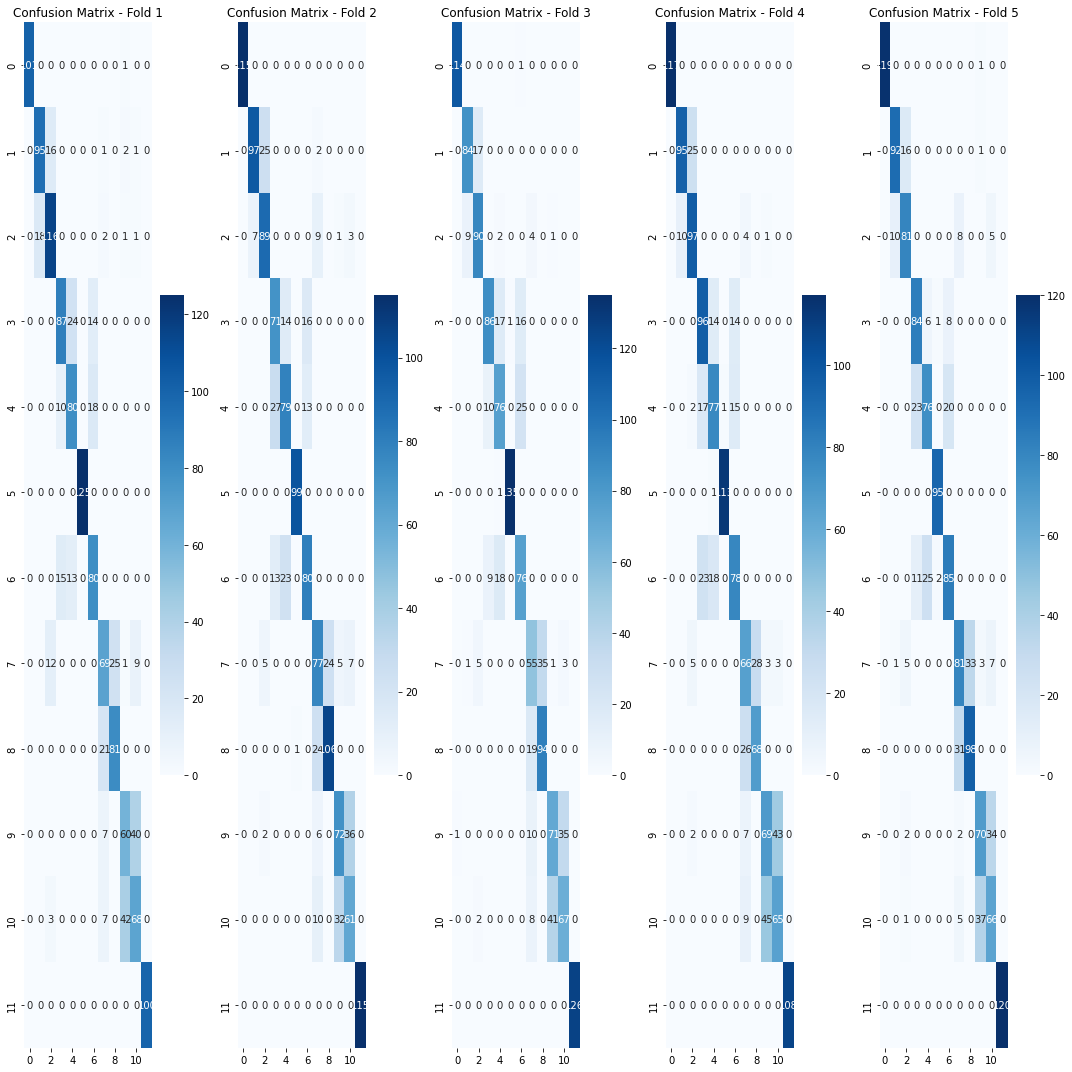


Cross-Validation Summary:
Accuracy: 0.7781 (±0.0059)
Precision: 0.7797 (±0.0058)
Recall: 0.7781 (±0.0059)
F1_score: 0.7780 (±0.0058)


In [7]:
# Data preparation
original_ds = pd.read_csv('./DS/original_ds.csv')
X = original_ds.drop('Label', axis=1)
y = original_ds['Label']
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y).astype(np.float32)
y = pd.Series(y)

# XGBoost multi-class classifier
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Perform cross-validation
cv_summary, detailed_reports = multiclass_kfold_cv(X, y, model)

# Print summary
print("\nCross-Validation Summary:")
for metric, stats in cv_summary.items():
    print(f"{metric.capitalize()}: {stats['mean']:.4f} (±{stats['std']:.4f})")